# Week 10 — Home exercise 4: One model per region

**Solution proposal.**

One elasticity for the whole world, or seven? The answer turns out to matter more than the method
does.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

plt.style.use("ggplot")

co2 = pd.read_csv("../data/co2_emissions.csv")
info = pd.read_csv("../data/country_info.csv")

panel = co2.merge(info[["code", "region"]], on="code", how="left", validate="many_to_one")
panel = panel[panel["region"] != "Aggregates"].dropna(subset=["co2_total"])
panel["co2_pc"] = panel["co2_total"] * 1_000_000 / panel["population"]

needed = ["co2_pc", "gdp_pc", "urban", "electricity", "renew_energy"]
countries = panel[panel["year"] == 2021].dropna(subset=needed)
countries = countries[countries["co2_pc"] > 0]

pooled = smf.ols("np.log(co2_pc) ~ np.log(gdp_pc)", data=countries).fit()
pooled_elasticity = pooled.params["np.log(gdp_pc)"]

print(len(countries), "countries | pooled elasticity", round(pooled_elasticity, 3))

194 countries | pooled elasticity 0.691


## 1. Seven regions, seven models - or fewer

In [2]:
results = []
skipped = []

for region in sorted(countries["region"].unique()):
    group = countries[countries["region"] == region]

    if len(group) < 10:
        skipped.append((region, len(group)))
        continue

    fit = smf.ols("np.log(co2_pc) ~ np.log(gdp_pc)", data=group).fit()
    interval = fit.conf_int().loc["np.log(gdp_pc)"]

    results.append({
        "region": region,
        "n": len(group),
        "elasticity": fit.params["np.log(gdp_pc)"],
        "ci_low": interval[0],
        "ci_high": interval[1],
        "r_squared": fit.rsquared,
    })

for region, n in skipped:
    print("skipped:", region, f"({n} countries)")

by_region = pd.DataFrame(results).sort_values("elasticity").reset_index(drop=True)
by_region.round(3)

skipped: North America (3 countries)
skipped: South Asia (6 countries)


,region,n,elasticity,ci_low,ci_high,r_squared
0,Latin America & Caribbean,37,0.126,-0.412,0.664,0.006
1,Europe & Central Asia,48,0.150,-0.069,0.369,0.040
2,East Asia & Pacific,33,0.574,-0.206,1.354,0.068
3,"Middle East, North Africa, Afghanistan & Pakistan",21,0.763,0.530,0.995,0.713
4,Sub-Saharan Africa,46,1.207,1.058,1.357,0.857


**Two regions skipped, and the guard was not hypothetical.** North America has three countries in this
table and South Asia has six. A regression on three points runs perfectly happily, returns a slope, an
R² and a confidence interval, and none of them means anything - with two parameters and three
observations there is one degree of freedom left.

Nothing warns you. The `if len(group) < 10: continue` is the warning, and it has to be written by you.

## 2. The picture

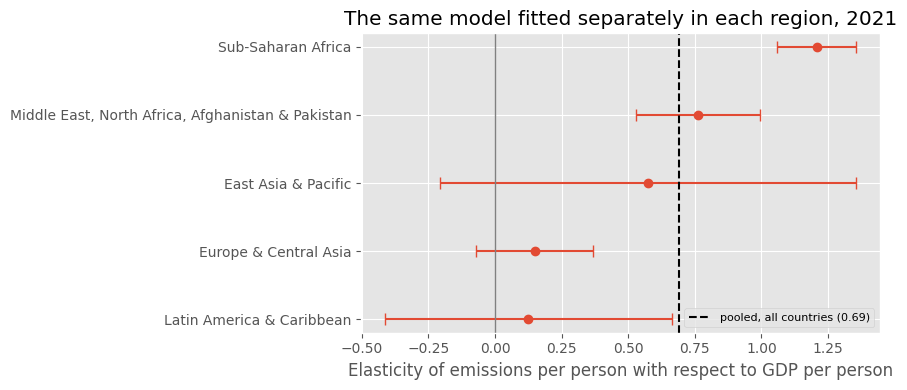

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.errorbar(
    by_region["elasticity"],
    by_region["region"],
    xerr=[by_region["elasticity"] - by_region["ci_low"],
          by_region["ci_high"] - by_region["elasticity"]],
    fmt="o",
    capsize=4,
)

ax.axvline(pooled_elasticity, color="black", linestyle="--",
           label=f"pooled, all countries ({pooled_elasticity:.2f})")
ax.axvline(0, color="gray", linewidth=1)

ax.set_xlabel("Elasticity of emissions per person with respect to GDP per person")
ax.set_title("The same model fitted separately in each region, 2021")
ax.legend(fontsize=8)

fig.tight_layout()

plt.show()

The pooled elasticity of 0.69 runs straight through the middle of a set of regional estimates that
range from 0.13 to 1.21 - and it describes almost none of them.

## 3. Two intervals that do not overlap

In [4]:
extremes = by_region[by_region["region"].isin(["Europe & Central Asia", "Sub-Saharan Africa"])]

extremes[["region", "n", "elasticity", "ci_low", "ci_high"]].round(3)

,region,n,elasticity,ci_low,ci_high
1,Europe & Central Asia,48,0.150,-0.069,0.369
4,Sub-Saharan Africa,46,1.207,1.058,1.357


**Europe and Central Asia: 0.15, interval -0.07 to 0.37. Sub-Saharan Africa: 1.21, interval 1.06 to
1.36.** The two intervals are nowhere near each other.

In plain language: **in Sub-Saharan Africa, a country with 10% higher income per person emits about 12%
more per person. In Europe and Central Asia, a country with 10% higher income emits perhaps 1.5% more,
and possibly nothing more at all.**

The relationship between income and emissions is not one relationship. In the poorer half of the world
it is close to proportional and slightly steeper; in the richer half it has more or less flattened out.
Pooling the two and reporting 0.69 describes a world in which no region actually lives.

## 4. The interval containing zero

**Three of the five do**, in fact - Latin America & Caribbean, Europe & Central Asia and East Asia &
Pacific - so this is the common case rather than the exception. Take Europe and Central Asia: its
interval runs from **-0.07 to 0.37**, so zero is inside it.

**That does not mean there is no relationship there.** It means this sample of 48 countries cannot
distinguish the relationship from zero - which is a statement about the evidence, not about Europe.
Three things could produce it, and the data does not choose between them:

- there really is no relationship among these countries at this income level
- there is one, and 48 countries with a narrow income range is not enough to see it
- there is one, and it is being obscured by something else that varies across these countries

Note also that the interval is not symmetric about nothing useful: it stretches to **+0.37**, which
would be a substantial relationship. "Not significantly different from zero" and "small" are different
claims, and only the first one has been demonstrated.

> ⚠️ **Warning:** An interval containing zero is a failure to rule zero out. It is not evidence that
the effect *is* zero, and reporting it that way is one of the most common mistakes made with
regression output.

## 5. One interacted model instead

In [5]:
interacted = smf.ols("np.log(co2_pc) ~ np.log(gdp_pc) * C(region)", data=countries).fit()

interacted.params.round(3)

Intercept                                                                        -4.942
C(region)[T.Europe & Central Asia]                                                5.064
C(region)[T.Latin America & Caribbean]                                            4.397
C(region)[T.Middle East, North Africa, Afghanistan & Pakistan]                   -0.307
C(region)[T.North America]                                                       28.307
C(region)[T.South Asia]                                                          -0.764
C(region)[T.Sub-Saharan Africa]                                                  -4.754
np.log(gdp_pc)                                                                    0.574
np.log(gdp_pc):C(region)[T.Europe & Central Asia]                                -0.424
np.log(gdp_pc):C(region)[T.Latin America & Caribbean]                            -0.448
np.log(gdp_pc):C(region)[T.Middle East, North Africa, Afghanistan & Pakistan]     0.189
np.log(gdp_pc):C(region)[T.North

The reference region is the one with no term of its own: **East Asia & Pacific**, alphabetically first.
Its slope is the plain `np.log(gdp_pc)` coefficient, and every other region's slope is that plus its
own interaction term.

In [6]:
baseline = interacted.params["np.log(gdp_pc)"]

reconstructed = []
for region in sorted(countries["region"].unique()):
    term = f"np.log(gdp_pc):C(region)[T.{region}]"
    adjustment = interacted.params[term] if term in interacted.params else 0.0
    reconstructed.append({"region": region, "from the interaction": baseline + adjustment})

check = pd.DataFrame(reconstructed).merge(
    by_region[["region", "n", "elasticity"]].rename(columns={"elasticity": "from the loop"}),
    on="region",
    how="left",
)

check.round(3)

,region,from the interaction,n,from the loop
0,East Asia & Pacific,0.574,33.0,0.574
1,Europe & Central Asia,0.150,48.0,0.150
2,Latin America & Caribbean,0.126,37.0,0.126
3,"Middle East, North Africa, Afghanistan & Pakistan",0.763,21.0,0.763
4,North America,-1.883,NaN,NaN
5,South Asia,0.742,NaN,NaN
6,Sub-Saharan Africa,1.207,46.0,1.207


**Identical wherever both exist**, to three decimals. The interacted model also produces slopes for
North America and South Asia - the two the loop refused to fit - and they are exactly as trustworthy
as they were before, which is to say not at all. Putting them in one big model does not create
information that three observations did not have.

## 6. Which one goes in the report?

**The loop, with the interacted model behind it.** They answer different questions and only one of
them is the question here.

| | Answers | Costs |
|---|---|---|
| **Seven separate fits** | *What is the elasticity in each region?* | Cannot test whether the regions differ. Each fit has its own everything, so nothing is shared |
| **One interacted model** | *Do the regions differ, and by how much?* | Assumes one residual variance for all of them. Reads as a wall of coefficients no reader will decode |

For a report about **income and emissions around the world**, the seven-row table and the error-bar
figure are what a reader can use: seven numbers, seven intervals, and a visible answer to whether they
are the same. That figure is the deliverable.

The interacted model is what I would run to **check** it - specifically, to get a p-value on whether
Sub-Saharan Africa's slope really differs from the reference region rather than eyeballing two
intervals. It belongs in an appendix or a footnote, not in the body.

And the pooled 0.69 from exercise 3 belongs in neither, now that we know what it is averaging.

### Things worth noticing

- **The `if len(group) < 10: continue` fired twice on real data.** That guard was the least interesting
  line in the lecture and it did more work here than anything else in the loop.
- **`term in interacted.params`** handles the reference region without a special case, because the
  reference category has no interaction term to look up. Asking whether a label exists before using it
  is cheaper than remembering which one is missing.
- **The error-bar figure is the whole exercise in one picture.** Seven point estimates and their
  uncertainty, with the pooled estimate drawn through them, says everything the tables say and says it
  faster.

### What this notebook does NOT do

- **It uses the region labels as given.** "Europe & Central Asia" contains countries with very little
  in common, and the elasticity estimated inside it is an average over that variety. Different regional
  definitions would give different answers.
- **It never asks whether the log-log shape is right *within* each region.** The pooled residual plot
  in exercise 3 looked acceptable; nothing here checks the seven separate ones, and a region with 46
  countries can easily hide a curve.
- **Seven models fitted, seven intervals reported, and no adjustment made for having looked seven
  times.** Testing many things and reporting the striking one is a real problem with this workflow,
  and it is not addressed here.
- **It is still one year.** Everything in exercises 3 and 4 describes 2021.